## Crypto 15m 趋势强度

In [228]:
import polars as pl
import numpy as np
import pandas as pd

In [229]:
# Crypto Parquet 数据读取（15m 多币种 K 线）
from pathlib import Path

DATA_PATH = Path("/hotdata/hot_kline_data/small_universe_kline_15m_train.parquet")
WINDOW = 60
LABEL_WINDOW = 8

if not DATA_PATH.exists():
    raise FileNotFoundError(f"未找到 Parquet 文件: {DATA_PATH}")

data = (
    pl.scan_parquet(DATA_PATH)
    .select([
        pl.col("interval"),
        pl.col("symbol").alias("udl"),
        pl.col("open_time").alias("samp_ts"),
        pl.col("close_time"),
        pl.col("open").cast(pl.Float64),
        pl.col("high").cast(pl.Float64),
        pl.col("low").cast(pl.Float64),
        pl.col("close").cast(pl.Float64),
        pl.col("volume").cast(pl.Float64),
        pl.col("quote_volume").cast(pl.Float64),
        pl.col("count"),
        pl.col("taker_buy_volume").cast(pl.Float64),
        pl.col("taker_buy_quote_volume").cast(pl.Float64),
    ])
    .with_columns(
        pl.col("samp_ts").dt.strftime("%Y%m%d").cast(pl.Int32).alias("d")
    )
    .select([
        "d",
        "samp_ts",
        "udl",
        "interval",
        "close_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_volume",
        "count",
        "taker_buy_volume",
        "taker_buy_quote_volume",
    ])
    .sort(["udl", "samp_ts"])
    .collect()
)

data.head(10)


d,samp_ts,udl,interval,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume
i32,"datetime[ms, Asia/Shanghai]",str,str,"datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,f64,f64
20231122,2023-11-22 22:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 22:14:59.999 CST,0.00478,0.004825,0.004611,0.004662,2.82492488e8,1.3289e6,7773,1.41717862e8,667078.945103
20231122,2023-11-22 22:15:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 22:29:59.999 CST,0.004664,0.00467,0.004541,0.004641,2.39726794e8,1.1067e6,5701,1.16646927e8,539217.836176
20231122,2023-11-22 22:30:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 22:44:59.999 CST,0.004641,0.004667,0.004404,0.004464,3.68985585e8,1.6639e6,8443,1.66574623e8,750368.288545
20231122,2023-11-22 22:45:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 22:59:59.999 CST,0.004464,0.004476,0.004107,0.004282,8.90519914e8,3.7754e6,16385,4.48449346e8,1.9005e6
20231122,2023-11-22 23:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 23:14:59.999 CST,0.004282,0.004388,0.004076,0.004245,8.99015323e8,3.7940e6,18029,4.30741128e8,1.8206e6
20231122,2023-11-22 23:15:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 23:29:59.999 CST,0.00424,0.004454,0.004176,0.004365,6.46110366e8,2.7731e6,13112,3.40997828e8,1.4651e6
20231122,2023-11-22 23:30:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 23:44:59.999 CST,0.004368,0.00447,0.004296,0.004347,4.60402263e8,2.0136e6,9680,2.01796608e8,883670.802685
20231122,2023-11-22 23:45:00 CST,"""1000BONKUSDT""","""15m""",2023-11-22 23:59:59.999 CST,0.00435,0.004368,0.00413,0.004252,5.3118551e8,2.2502e6,11624,2.56477852e8,1.0866e6
20231123,2023-11-23 00:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 00:14:59.999 CST,0.004254,0.004413,0.004233,0.00438,4.91146686e8,2.1346e6,12203,2.4883729e8,1.0827e6


In [230]:
data = data.with_columns(
    (pl.col("close") - pl.col("close").shift(WINDOW)).over("udl").alias("Weiyi"),
    (pl.col("close") - pl.col("close").shift(1)).abs().over("udl").alias("single_length"),
)

data = data.with_columns(
    pl.col("single_length")
    .rolling_sum(window_size=WINDOW, min_samples=WINDOW)
    .over("udl")
    .alias("lucheng")
)

data = data.drop_nulls()

data

d,samp_ts,udl,interval,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,Weiyi,single_length,lucheng
i32,"datetime[ms, Asia/Shanghai]",str,str,"datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64
20231123,2023-11-23 13:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:14:59.999 CST,0.004291,0.004348,0.00428,0.004327,1.37580258e8,594440.837508,3978,7.0549981e7,305093.213299,-0.000335,0.000033,0.003795
20231123,2023-11-23 13:15:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:29:59.999 CST,0.004325,0.004331,0.004201,0.004279,2.5624341e8,1.0932e6,7778,9.1383992e7,390160.227019,-0.000362,0.000048,0.003822
20231123,2023-11-23 13:30:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:44:59.999 CST,0.004279,0.004312,0.004214,0.004302,1.8522236e8,791410.482324,4513,9.4576226e7,404478.614139,-0.000162,0.000023,0.003668
20231123,2023-11-23 13:45:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:59:59.999 CST,0.004302,0.004304,0.00426,0.004284,7.7741716e7,333194.403599,2075,3.3743881e7,144696.136468,0.000002,0.000018,0.003504
20231123,2023-11-23 14:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 14:14:59.999 CST,0.004284,0.004286,0.004195,0.004231,2.23740256e8,948161.455951,6342,9.7693911e7,414375.805785,-0.000014,0.000053,0.00352
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20251231,2025-12-31 22:45:00 CST,"""XRPUSDT""","""15m""",2025-12-31 22:59:59.999 CST,1.8677,1.8683,1.8629,1.8658,6402661.3,1.1944e7,19449,2647553.7,4.9394e6,-0.0107,0.0019,0.1083
20251231,2025-12-31 23:00:00 CST,"""XRPUSDT""","""15m""",2025-12-31 23:14:59.999 CST,1.8657,1.8668,1.855,1.8612,9611751.8,1.7879e7,24094,4442457.9,8.2629e6,-0.0116,0.0046,0.1092
20251231,2025-12-31 23:15:00 CST,"""XRPUSDT""","""15m""",2025-12-31 23:29:59.999 CST,1.8611,1.8614,1.8562,1.8573,6820829.4,1.2676e7,18962,2874801.6,5.3430e6,-0.0167,0.0039,0.1119


In [231]:
# data=data.drop_nulls()

In [232]:
# data=data.with_columns(
#     pl.col("single_length").rolling_sum(window_size=120,min_samples=1).over("udl").alias("lucheng")
# )

# data

In [233]:
data = data.with_columns(
    pl.when(pl.col("lucheng") != 0)
    .then(pl.col("Weiyi") / pl.col("lucheng"))
    .otherwise(None)
    .alias("factor")
)

data = data.drop_nulls(subset=["factor"])

data

d,samp_ts,udl,interval,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,Weiyi,single_length,lucheng,factor
i32,"datetime[ms, Asia/Shanghai]",str,str,"datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64
20231123,2023-11-23 13:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:14:59.999 CST,0.004291,0.004348,0.00428,0.004327,1.37580258e8,594440.837508,3978,7.0549981e7,305093.213299,-0.000335,0.000033,0.003795,-0.088274
20231123,2023-11-23 13:15:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:29:59.999 CST,0.004325,0.004331,0.004201,0.004279,2.5624341e8,1.0932e6,7778,9.1383992e7,390160.227019,-0.000362,0.000048,0.003822,-0.094715
20231123,2023-11-23 13:30:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:44:59.999 CST,0.004279,0.004312,0.004214,0.004302,1.8522236e8,791410.482324,4513,9.4576226e7,404478.614139,-0.000162,0.000023,0.003668,-0.044166
20231123,2023-11-23 13:45:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:59:59.999 CST,0.004302,0.004304,0.00426,0.004284,7.7741716e7,333194.403599,2075,3.3743881e7,144696.136468,0.000002,0.000018,0.003504,0.000571
20231123,2023-11-23 14:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 14:14:59.999 CST,0.004284,0.004286,0.004195,0.004231,2.23740256e8,948161.455951,6342,9.7693911e7,414375.805785,-0.000014,0.000053,0.00352,-0.003977
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20251231,2025-12-31 22:45:00 CST,"""XRPUSDT""","""15m""",2025-12-31 22:59:59.999 CST,1.8677,1.8683,1.8629,1.8658,6402661.3,1.1944e7,19449,2647553.7,4.9394e6,-0.0107,0.0019,0.1083,-0.0988
20251231,2025-12-31 23:00:00 CST,"""XRPUSDT""","""15m""",2025-12-31 23:14:59.999 CST,1.8657,1.8668,1.855,1.8612,9611751.8,1.7879e7,24094,4442457.9,8.2629e6,-0.0116,0.0046,0.1092,-0.106227
20251231,2025-12-31 23:15:00 CST,"""XRPUSDT""","""15m""",2025-12-31 23:29:59.999 CST,1.8611,1.8614,1.8562,1.8573,6820829.4,1.2676e7,18962,2874801.6,5.3430e6,-0.0167,0.0039,0.1119,-0.14924


In [234]:
data = data.with_columns(
    ((pl.col("close").shift(-1) / pl.col("close")) - 1).over("udl").alias("label1"),
    ((pl.col("close").shift(-LABEL_WINDOW) / pl.col("close")) - 1).over("udl").alias("label60"),
)

data = data.drop_nulls()

data

d,samp_ts,udl,interval,close_time,open,high,low,close,volume,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,Weiyi,single_length,lucheng,factor,label1,label60
i32,"datetime[ms, Asia/Shanghai]",str,str,"datetime[ms, Asia/Shanghai]",f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64
20231123,2023-11-23 13:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:14:59.999 CST,0.004291,0.004348,0.00428,0.004327,1.37580258e8,594440.837508,3978,7.0549981e7,305093.213299,-0.000335,0.000033,0.003795,-0.088274,-0.011093,-0.002311
20231123,2023-11-23 13:15:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:29:59.999 CST,0.004325,0.004331,0.004201,0.004279,2.5624341e8,1.0932e6,7778,9.1383992e7,390160.227019,-0.000362,0.000048,0.003822,-0.094715,0.005375,0.003739
20231123,2023-11-23 13:30:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:44:59.999 CST,0.004279,0.004312,0.004214,0.004302,1.8522236e8,791410.482324,4513,9.4576226e7,404478.614139,-0.000162,0.000023,0.003668,-0.044166,-0.004184,-0.009995
20231123,2023-11-23 13:45:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 13:59:59.999 CST,0.004302,0.004304,0.00426,0.004284,7.7741716e7,333194.403599,2075,3.3743881e7,144696.136468,0.000002,0.000018,0.003504,0.000571,-0.012372,0.005836
20231123,2023-11-23 14:00:00 CST,"""1000BONKUSDT""","""15m""",2023-11-23 14:14:59.999 CST,0.004284,0.004286,0.004195,0.004231,2.23740256e8,948161.455951,6342,9.7693911e7,414375.805785,-0.000014,0.000053,0.00352,-0.003977,-0.003073,0.026708
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20251231,2025-12-31 20:45:00 CST,"""XRPUSDT""","""15m""",2025-12-31 20:59:59.999 CST,1.8739,1.8762,1.8723,1.8752,2724204.2,5.1048e6,7203,1319111.1,2.4720e6,0.003,0.0013,0.102,0.029412,0.0008,-0.005013
20251231,2025-12-31 21:00:00 CST,"""XRPUSDT""","""15m""",2025-12-31 21:14:59.999 CST,1.8753,1.8773,1.8752,1.8767,1.524084e6,2.8599e6,5092,805329.5,1.5112e6,0.0001,0.0015,0.0991,0.001009,-0.000639,-0.008259
20251231,2025-12-31 21:15:00 CST,"""XRPUSDT""","""15m""",2025-12-31 21:29:59.999 CST,1.8768,1.8777,1.8752,1.8755,1812751.1,3.4021e6,5552,802665.7,1.5064e6,-0.0011,0.0012,0.1003,-0.010967,-0.001546,-0.009704


In [235]:
data=data.select(["samp_ts","d","udl","factor","label1","label60"])
data=data.drop_nans()
data

samp_ts,d,udl,factor,label1,label60
"datetime[ms, Asia/Shanghai]",i32,str,f64,f64,f64
2023-11-23 13:00:00 CST,20231123,"""1000BONKUSDT""",-0.088274,-0.011093,-0.002311
2023-11-23 13:15:00 CST,20231123,"""1000BONKUSDT""",-0.094715,0.005375,0.003739
2023-11-23 13:30:00 CST,20231123,"""1000BONKUSDT""",-0.044166,-0.004184,-0.009995
2023-11-23 13:45:00 CST,20231123,"""1000BONKUSDT""",0.000571,-0.012372,0.005836
2023-11-23 14:00:00 CST,20231123,"""1000BONKUSDT""",-0.003977,-0.003073,0.026708
…,…,…,…,…,…
2025-12-31 20:45:00 CST,20251231,"""XRPUSDT""",0.029412,0.0008,-0.005013
2025-12-31 21:00:00 CST,20251231,"""XRPUSDT""",0.001009,-0.000639,-0.008259
2025-12-31 21:15:00 CST,20251231,"""XRPUSDT""",-0.010967,-0.001546,-0.009704


In [236]:
data=data.with_columns(
    (pl.col("factor").ewm_mean(alpha=0.1,min_samples=1).over("udl")).alias("factor")
)

data=data.with_columns(
    (pl.col("factor").ewm_mean(alpha=0.1,min_samples=1).over("udl")).alias("factor")
)




data


samp_ts,d,udl,factor,label1,label60
"datetime[ms, Asia/Shanghai]",i32,str,f64,f64,f64
2023-11-23 13:00:00 CST,20231123,"""1000BONKUSDT""",-0.088274,-0.011093,-0.002311
2023-11-23 13:15:00 CST,20231123,"""1000BONKUSDT""",-0.090058,0.005375,0.003739
2023-11-23 13:30:00 CST,20231123,"""1000BONKUSDT""",-0.084183,-0.004184,-0.009995
2023-11-23 13:45:00 CST,20231123,"""1000BONKUSDT""",-0.074945,-0.012372,0.005836
2023-11-23 14:00:00 CST,20231123,"""1000BONKUSDT""",-0.066555,-0.003073,0.026708
…,…,…,…,…,…
2025-12-31 20:45:00 CST,20251231,"""XRPUSDT""",-0.008374,0.0008,-0.005013
2025-12-31 21:00:00 CST,20251231,"""XRPUSDT""",-0.006653,-0.000639,-0.008259
2025-12-31 21:15:00 CST,20251231,"""XRPUSDT""",-0.005302,-0.001546,-0.009704


In [237]:
# data 应包含: samp_ts, d, udl, factor, label1, label60
# 转换为 pandas 方便沿用相关性统计。
df_pd = data.to_pandas()

# 计算总体 IC
overall_ic = df_pd["factor"].corr(df_pd["label60"]) * 100

# 计算平均每日换手；15m 数据自然日最多 96 根，但这里直接按实际 d 去重。
n_symbols = df_pd["udl"].nunique()
n_days = max(df_pd["d"].nunique(), 1)
mtvr = df_pd.groupby("udl")["factor"].diff().abs().sum() / n_symbols / n_days

# 添加年份列
df_pd["year"] = pd.to_datetime(df_pd["samp_ts"]).dt.year

# 计算年度 IC
yearly_ic = df_pd.groupby("year")[["factor", "label60"]].corr().unstack()["label60"]["factor"] * 100

print(f"all ic: {overall_ic:.4f}, daily mtvr: {mtvr:.6f}")
yearly_ic

all ic: 0.8296, daily mtvr: 0.260138


year
2022    1.262943
2023    1.096978
2024    0.862412
2025    0.341797
Name: factor, dtype: float64

In [238]:
# Min-Max缩放到[-1,1]区间
data = data.with_columns(
    (2 * (pl.col("factor") - pl.col("factor").rolling_min(window_size = 5000).over("udl")) / 
     (pl.col("factor").rolling_max(window_size = 5000).over("udl") - pl.col("factor").rolling_min(window_size = 5000).over("udl") + 1e-10) - 1)
    .alias("factor")
)

data = data.drop_nans()
data = data.drop_nulls()

In [239]:
data = data.filter(pl.col("d") >= 20240101)

In [240]:
data

samp_ts,d,udl,factor,label1,label60
"datetime[ms, Asia/Shanghai]",i32,str,f64,f64,f64
2024-01-14 14:45:00 CST,20240114,"""1000BONKUSDT""",0.499308,0.013747,-0.008625
2024-01-14 15:00:00 CST,20240114,"""1000BONKUSDT""",0.493784,-0.014956,-0.026389
2024-01-14 15:15:00 CST,20240114,"""1000BONKUSDT""",0.488232,-0.007625,-0.003914
2024-01-14 15:30:00 CST,20240114,"""1000BONKUSDT""",0.481717,0.005372,0.002312
2024-01-14 15:45:00 CST,20240114,"""1000BONKUSDT""",0.475264,-0.004599,0.003517
…,…,…,…,…,…
2025-12-31 20:45:00 CST,20251231,"""XRPUSDT""",-0.017305,0.0008,-0.005013
2025-12-31 21:00:00 CST,20251231,"""XRPUSDT""",-0.012963,-0.000639,-0.008259
2025-12-31 21:15:00 CST,20251231,"""XRPUSDT""",-0.009554,-0.001546,-0.009704


In [241]:
# 第一步：计算单期边际收益
data = data.with_columns(
    (pl.col("factor") * pl.col("label1").shift(-1).over("udl")).alias("margin_return")
)

data=data.fill_null(0)

# 第二步：计算累积边际收益
data = data.with_columns(
    pl.col("margin_return").cum_sum().over("udl").alias("cumulative_return")
)

# 第三步：先创建 position_change 列（相当于您代码中的abs_diff）
data = data.with_columns(
    pl.col("factor").diff().abs().over("udl").alias("position_change")
)

# 第四步：再使用 position_change 列计算 cumulative_turnover
data = data.with_columns(
    pl.col("position_change").cum_sum().over("udl").alias("cumulative_turnover")
)

# 获取每个品种最后一行的数据（相当于您代码中的last()）
final_stats = data.group_by("udl").agg(
    pl.col("cumulative_return").last().alias("ret"),
    pl.col("cumulative_turnover").last().alias("abs_diff")
)

# 计算ret/abs_diff（相当于您代码中的ret/abs_diff）
final_stats = final_stats.with_columns(
    (pl.col("ret") / pl.col("abs_diff") * 10000).alias("ret_per_turnover")
)

# 按ret降序排序
sorted_stats = final_stats.sort("ret", descending=True)

# 计算ret/abs_diff的平均值
avg_ret_per_turnover = final_stats.select(pl.mean("ret_per_turnover")).item()

# 输出结果
print(f"平均每单位换手收益率（×10000）: {avg_ret_per_turnover}")

# 返回排序后的结果
sorted_stats

平均每单位换手收益率（×10000）: 4.7987795555632


udl,ret,abs_diff,ret_per_turnover
str,f64,f64,f64
"""1000PEPEUSDT""",1.554074,726.384129,21.394665
"""ORDIUSDT""",1.143657,683.271693,16.737952
"""XRPUSDT""",1.039381,728.460736,14.268188
"""WLDUSDT""",1.005995,720.071656,13.97076
"""DOGEUSDT""",0.966696,740.261162,13.058855
…,…,…,…
"""HYPEUSDT""",-0.170492,161.318257,-10.568692
"""ADAUSDT""",-0.259954,733.438897,-3.544316
"""NEIROUSDT""",-0.269815,405.624032,-6.651846


In [242]:
sorted_stats.write_csv('sorted_stats.csv')

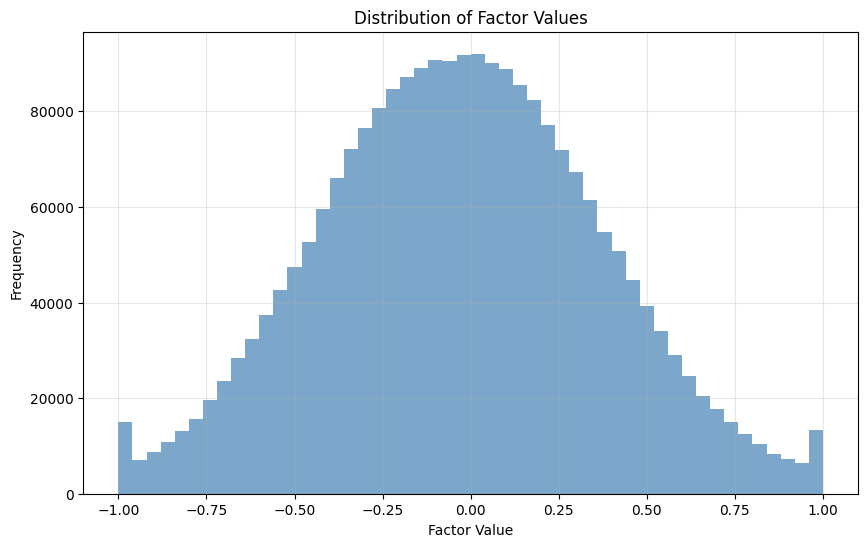

In [243]:
import matplotlib.pyplot as plt

# 绘制factor的分布图
plt.figure(figsize=(10, 6))
plt.hist(data['factor'].to_numpy(), bins=50, color='steelblue', alpha=0.7)
plt.title('Distribution of Factor Values')
plt.xlabel('Factor Value')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()